In [1]:
import mlflow
import numpy as np
import pylab as plt
import pandas as pd

In [39]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/optimal_al/645771664333558840/
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/meta.yaml
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/artifacts/
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/ACE
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/BS
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/ECE
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/NLL
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/accuracy
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/query_time
perf_dal/optimal_al/645771664333558840/0d751dc0f474480da2c5b4e1429ac2f6/metrics/reliability
pe

In [40]:
# client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:///decision_flips.db')
# experiment_id = client.get_experiment_by_name('decision_flips').experiment_id
client = mlflow.tracking.MlflowClient(tracking_uri=f'file:////home/dhuseljic/mlflow/perf_dal/optimal_al/')
# experiment_id = client.get_experiment_by_name('num_batches_v1').experiment_id
experiment_id = client.get_experiment_by_name('mc_samples').experiment_id
query_list = [
    "parameter.dataset_name= 'cifar10'",
    # "parameter.al.gamma = '1'",
]
runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs)))

Found 59 experiments


In [41]:
from collections import defaultdict

acc_curves = defaultdict(list)
# num_batches_unique = np.unique([int(run.data.params['al.num_batches']) for run in runs])

for run in runs:
    # key = run.data.params['al.strategy']
    # key = int(run.data.params['al.num_batches'])
    key = int(run.data.params['al.num_mc_labels'])
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

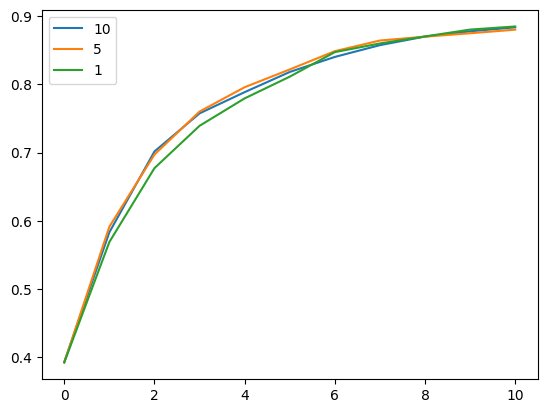

In [42]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0), label=key)
    # plt.plot(np.mean(acc_curves[key]- np.mean(acc_curves[50], axis=0) , axis=0), label=key)
plt.legend()